In [1]:
# Import libraries and load datasets
import pandas as pd, numpy as np

# Load data
pizza_names = pd.read_csv('pizza_names.csv')
pizza_toppings = pd.read_csv('pizza_toppings.csv')
pizza_recipes = pd.read_csv('pizza_recipes.csv')
customer_orders = pd.read_csv('customer_orders.csv', parse_dates=['order_date'])
runner_orders = pd.read_csv('runner_orders.csv', parse_dates=['pickup_time'])
runners = pd.read_csv('runners.csv', parse_dates=['registration_date'])

# Clean distance

def parse_distance(x):
    if pd.isna(x) or x == '':
        return np.nan
    x = str(x).strip()
    x = x.replace('km','').replace(' ','')
    try:
        return float(x)
    except:
        return np.nan

runner_orders['distance_km'] = runner_orders['distance'].apply(parse_distance)

# Clean duration

def parse_duration(x):
    if pd.isna(x) or x == '':
        return np.nan
    x = str(x).strip().lower()
    x = x.replace('minutes','').replace('minute','').replace('mins','').replace('min','').replace(' ', '')
    try:
        return float(x)
    except:
        return np.nan

runner_orders['duration_min'] = runner_orders['duration'].apply(parse_duration)

# Clean cancellation
runner_orders['cancellation'] = runner_orders['cancellation'].replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan})
runner_orders['delivered'] = runner_orders['cancellation'].isna()

# Merge orders with runner info
merged = customer_orders.merge(runner_orders[['order_id','runner_id','pickup_time','distance_km','duration_min','delivered']], on='order_id', how='left')

# Compute prep time (minutes) between customer order and pickup time
merged['prep_time_min'] = (merged['pickup_time'] - merged['order_date']).dt.total_seconds() / 60

# Derived columns for hour and day
customer_orders['order_hour'] = customer_orders['order_date'].dt.hour
customer_orders['order_day'] = customer_orders['order_date'].dt.day_name()# Compute metrics for case study questions

# A1: total pizzas ordered and unique orders
num_pizzas_ordered = len(customer_orders)
num_unique_orders = customer_orders['order_id'].nunique()

# A3: successful orders delivered by each runner
success_by_runner = runner_orders[runner_orders['delivered']].groupby('runner_id')['order_id'].nunique().reset_index(name='successful_orders')

# A4: number of each type of pizza delivered
# Filter delivered orders using merged dataset
from IPython.display import display

delivered_orders = merged[merged['delivered'] == True]
delivered_by_pizza = delivered_orders.groupby('pizza_id')['order_id'].count().reset_index(name='delivered_orders')
pizza_counts = delivered_by_pizza.merge(pizza_names, on='pizza_id')[['pizza_name','delivered_orders']].sort_values('delivered_orders', ascending=False)

# A5: Vegetarian and Meat Lovers orders per customer
vm_orders = delivered_orders[delivered_orders['pizza_id'].isin([2,3])]
vm_counts = vm_orders.groupby(['customer_id','pizza_id']).size().unstack(fill_value=0)
vm_counts = vm_counts.rename(columns={2:'vegetarian', 3:'meat_lovers'})

# A6: maximum pizzas delivered in a single order
max_pizzas_per_order = delivered_orders.groupby('order_id').size().max()

# A7: count of delivered pizzas with change (exclusions or extras) vs no change per customer
def has_change(row):
    return (pd.notna(row['exclusions']) and str(row['exclusions']).strip() != '') or (pd.notna(row['extras']) and str(row['extras']).strip() != '')

delivered_orders['has_change'] = delivered_orders.apply(has_change, axis=1)
customer_change_counts = delivered_orders.groupby(['customer_id','has_change']).size().unstack(fill_value=0).rename(columns={False:'no_change', True:'has_change'})

# A8: pizzas delivered with both exclusions and extras
def has_both(row):
    return (pd.notna(row['exclusions']) and str(row['exclusions']).strip() != '') and (pd.notna(row['extras']) and str(row['extras']).strip() != '')
both_exclusions_extras = delivered_orders.apply(has_both, axis=1).sum()

# A9: volume of pizzas ordered per hour
volume_by_hour = customer_orders.groupby('order_hour')['order_id'].count()

# A10: volume of orders per day of week
volume_by_day = customer_orders['order_day'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

# B1: runners signed up each week (weeks starting 2021-01-01)
start_date = pd.to_datetime('2021-01-01')
runners['week_number'] = ((runners['registration_date'] - start_date).dt.days // 7) + 1
runners_per_week = runners.groupby('week_number')['runner_id'].count()

# B2: average prep time (minutes) for each runner
avg_prep_by_runner = merged[merged['delivered']==True].groupby('runner_id')['prep_time_min'].mean().reset_index()

# B3: correlation between number of pizzas and order prep time
order_pizza_counts = merged.groupby('order_id')['pizza_id'].count().reset_index(name='pizza_count')
prep_time_per_order = merged.groupby('order_id')['prep_time_min'].first().reset_index()
order_prep = order_pizza_counts.merge(prep_time_per_order, on='order_id')
corr_prep = order_prep['pizza_count'].corr(order_prep['prep_time_min'])

# B4: average distance per customer
avg_distance_per_customer = delivered_orders.groupby('customer_id')['distance_km'].mean().reset_index().rename(columns={'distance_km':'avg_distance_km'})

# B5: difference between longest and shortest delivery times
max_duration = runner_orders.loc[runner_orders['delivered'], 'duration_min'].max()
min_duration = runner_orders.loc[runner_orders['delivered'], 'duration_min'].min()
diff_duration = max_duration - min_duration

# B6: average speed (km/h) by runner
runner_orders['speed_kmh'] = runner_orders.apply(lambda row: row['distance_km'] / row['duration_min'] * 60 if row['delivered'] and row['duration_min']>0 else np.nan, axis=1)
avg_speed_by_runner = runner_orders.groupby('runner_id')['speed_kmh'].mean().reset_index()

# B7: successful delivery percentage by runner
orders_per_runner = runner_orders.groupby('runner_id')['order_id'].count()
success_rate = (runner_orders[runner_orders['delivered']].groupby('runner_id')['order_id'].count() / orders_per_runner * 100).reset_index(name='success_percentage')

# C1: approximate customer spend (base $10 per pizza + $1 per extra)
def count_extras(extras):
    if pd.isna(extras) or str(extras).strip() == '':
        return 0
    return len([e for e in str(extras).split(',') if e.strip() != ''])

customer_orders['extras_count'] = customer_orders['extras'].apply(count_extras)
customer_orders['order_value'] = 10 + customer_orders['extras_count']
spend_by_customer = customer_orders.groupby('customer_id')['order_value'].sum().reset_index().sort_values('order_value', ascending=False)

# C2: customer frequency (distinct order days)
customer_orders['order_date_only'] = customer_orders['order_date'].dt.date
frequency_by_customer = customer_orders.groupby('customer_id')['order_date_only'].nunique().reset_index().rename(columns={'order_date_only':'distinct_order_days'})

# C3: first pizza ordered by each customer
first_orders = customer_orders.sort_values('order_date').groupby('customer_id').first().reset_index()
first_pizza = first_orders[['customer_id','pizza_id']].merge(pizza_names, on='pizza_id')
first_pizza_counts = first_pizza.groupby('pizza_name')['customer_id'].nunique().reset_index(name='first_order_count').sort_values('first_order_count', ascending=False)

# C4: overall best-seller pizza
pizza_sales = customer_orders['pizza_id'].value_counts().reset_index()
pizza_sales.columns = ['pizza_id','count']
pizza_sales = pizza_sales.merge(pizza_names, on='pizza_id').sort_values('count', ascending=False)

# C5: most popular pizza per customer
popular_by_customer = customer_orders.groupby(['customer_id','pizza_id']).size().reset_index(name='count')
popular_by_customer = popular_by_customer.sort_values(['customer_id','count'], ascending=[True, False])
popular_top = popular_by_customer.groupby('customer_id').first().reset_index().merge(pizza_names, on='pizza_id')

# Display some key results
display(pd.DataFrame({'Metric':['Total pizzas ordered','Unique orders','Max pizzas per order','Delivered with both exclusions & extras','Prep time vs pizza count correlation','Duration difference (minutes)'],
                     'Value':[num_pizzas_ordered, num_unique_orders, max_pizzas_per_order, both_exclusions_extras, corr_prep, diff_duration]}))

# Show success by runner
print('\nSuccessful orders by runner:')
display(success_by_runner)

print('\nDelivered pizzas by type:')
display(pizza_counts)

print('\nVegetarian & Meat Lovers orders by customer (sample):')
display(vm_counts.head())

print('\nCustomer change counts (sample):')
display(customer_change_counts.head())

print('\nOrders volume by hour:')
display(volume_by_hour.to_frame(name='orders'))

print('\nOrders volume by day:')
display(volume_by_day.to_frame(name='orders'))

print('\nRunners per week:')
display(runners_per_week.to_frame(name='runner_signups'))

print('\nAverage prep time by runner (minutes) sample:')
display(avg_prep_by_runner.head())

print('\nAverage distance per customer (km) sample:')
display(avg_distance_per_customer.head())

print('\nAverage speed by runner (km/h) sample:')
display(avg_speed_by_runner.head())

print('\nSuccessful delivery percentage by runner:')
display(success_rate)

print('\nTop 5 spenders:')
display(spend_by_customer.head())

print('\nCustomer order frequency (sample):')
display(frequency_by_customer.head())

print('\nFirst pizza counts:')
display(first_pizza_counts)

print('\nBest-seller pizzas:')
display(pizza_sales)

print('\nMost popular pizza per customer (sample):')
display(popular_top.head())

C:\Users\luisn\AppData\Local\Temp\ipykernel_15076\1554399164.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['has_change'] = delivered_orders.apply(has_change, axis=1)


,Metric,Value
0,Total pizzas ordered,2101.000000
1,Unique orders,1500.000000
2,Max pizzas per order,4.000000
3,Delivered with both exclusions & extras,192.000000
4,Prep time vs pizza count correlation,-0.030723
5,Duration difference (minutes),48.000000



Successful orders by runner:


,runner_id,successful_orders
0,1,93
1,2,110
2,3,115
3,4,90
4,5,109
5,6,80
6,7,101
7,8,92
8,9,87
9,10,89



Delivered pizzas by type:


...

,pizza_name,first_order_count
3,Meat Lovers,138
4,Pepperoni,94
6,Vegetarian,94
0,BBQ Chicken,71
2,Margherita,69
1,Hawaiian,61
5,Vegan Veggie,41



Best-seller pizzas:


,pizza_id,count,pizza_name
0,3,468,Meat Lovers
1,6,398,Pepperoni
2,2,340,Vegetarian
3,4,278,BBQ Chicken
4,1,235,Margherita
5,5,218,Hawaiian
6,7,164,Vegan Veggie



Most popular pizza per customer (sample):


,customer_id,pizza_id,count,pizza_name
0,1,3,1,Meat Lovers
1,3,3,1,Meat Lovers
2,5,3,7,Meat Lovers
3,10,3,1,Meat Lovers
4,13,3,2,Meat Lovers


## Visualizaciones

A continuación se presentan algunas gráficas que resumen los patrones de pedidos, la popularidad de las pizzas y el rendimiento de los repartidores.

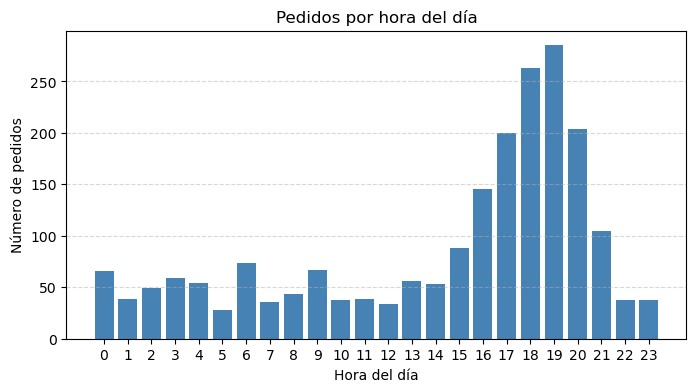

In [2]:

# Gráfica: Pedidos por hora del día
import matplotlib.pyplot as plt
import pandas as pd

# Calcular el número de pedidos por hora
df_orders = customer_orders.copy()
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
hour_counts = df_orders['order_date'].dt.hour.value_counts().sort_index()

# Crear la gráfica
plt.figure(figsize=(8,4))
plt.bar(hour_counts.index, hour_counts.values, color='steelblue')
plt.title('Pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


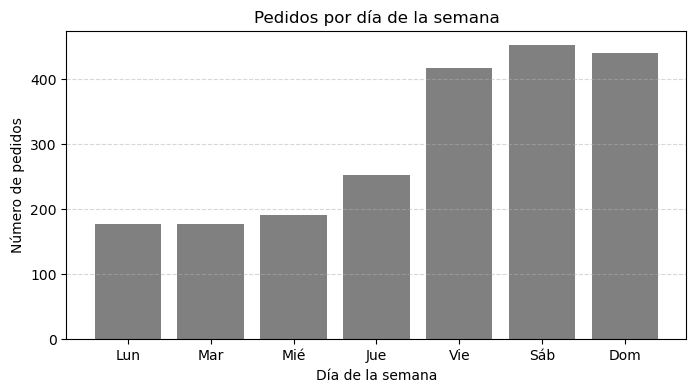

In [3]:

# Gráfica: Pedidos por día de la semana
import matplotlib.pyplot as plt
import pandas as pd

# Calcular el número de pedidos por día de la semana
df_orders['day_name'] = df_orders['order_date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df_orders['day_name'].value_counts().reindex(day_order)

# Crear la gráfica
plt.figure(figsize=(8,4))
plt.bar(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'], day_counts.values, color='gray')
plt.title('Pedidos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Número de pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


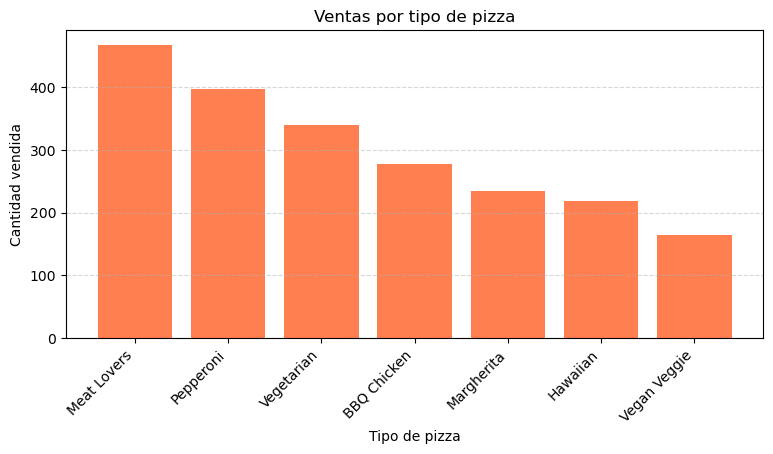

In [4]:

# Gráfica: Popularidad de pizzas
import matplotlib.pyplot as plt

# Obtener el nombre de la pizza para cada pedido
pizza_name_map = pizza_names.set_index('pizza_id')['pizza_name']
pizza_counts = customer_orders['pizza_id'].map(pizza_name_map).value_counts()

plt.figure(figsize=(9,4))
plt.bar(pizza_counts.index, pizza_counts.values, color='coral')
plt.title('Ventas por tipo de pizza')
plt.xlabel('Tipo de pizza')
plt.ylabel('Cantidad vendida')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


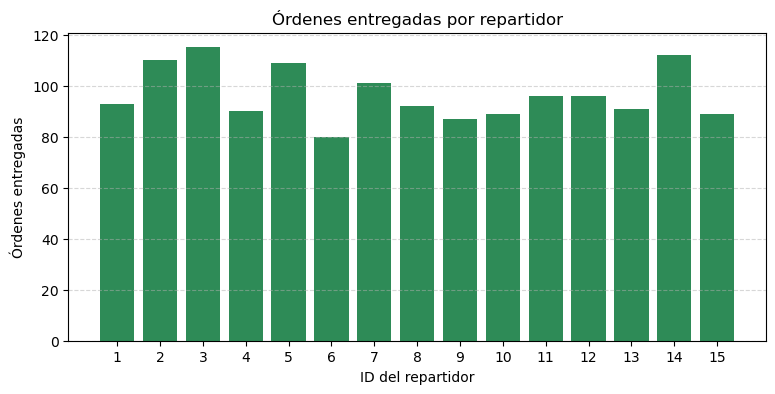

In [5]:

# Gráfica: Rendimiento de repartidores
import matplotlib.pyplot as plt

# Filtrar órdenes exitosas (sin cancelación)
successful_orders = runner_orders[runner_orders['cancellation'].isna()]
runner_counts = successful_orders['runner_id'].value_counts().sort_index()

plt.figure(figsize=(9,4))
plt.bar(runner_counts.index.astype(str), runner_counts.values, color='seagreen')
plt.title('Órdenes entregadas por repartidor')
plt.xlabel('ID del repartidor')
plt.ylabel('Órdenes entregadas')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
